# 06 — Ensemble Lab

**Goal**: Determine the best model configuration for solubility prediction.  
We train every base model individually, measure their prediction correlation, then test three ensemble strategies (voting, blending, stacking) before and after hyperparameter tuning.  
The winning configuration here is what gets serialised for the prediction API in Phase 7.

**Evaluation**: TDC benchmark scaffold split throughout — the same fixed test set used by the leaderboard, so results are directly comparable.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from molgate.data.loaders import load_tdc_benchmark_split
from molgate.data.splits import random_split
from molgate.data.featurizer import compute_fingerprints, compute_descriptors, smiles_list_to_graphs
from molgate.models.factory import create_model
from molgate.models.ensemble import GNNModelWrapper
from molgate.training.metrics import compute_metrics

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42

## 1. Data

Load the TDC benchmark scaffold split.  We carve a small validation set from `train_val` for the blending meta-model and ensemble tuning — the test set is never touched until the final evaluation.

In [2]:
train_val_df, test_df = load_tdc_benchmark_split('solubility')

# 90 / 10 split of train_val → train / val
sub = random_split(train_val_df, val_frac=0.1, test_frac=0.0, seed=SEED)
train_df = sub['train']
val_df   = sub['val']

print(f'Train : {len(train_df):,} molecules')
print(f'Val   : {len(val_df):,} molecules')
print(f'Test  : {len(test_df):,} molecules (TDC fixed)')

Found local copy...


Train : 6,866 molecules
Val   : 762 molecules
Test  : 1,968 molecules (TDC fixed)


In [3]:
def featurize(df):
    """Return the feature dict used by all base models."""
    sm     = df['smiles'].tolist()
    y_vals = df['y'].tolist() if 'y' in df.columns else None
    fp     = compute_fingerprints(sm)          # (N, 2048)
    desc   = compute_descriptors(sm).values    # (N, 12)
    return {
        'lgbm_morgan':       fp,
        'lgbm_descriptors':  desc,
        'rf_descriptors':    desc,
        'gnn':               smiles_list_to_graphs(sm, y_vals),
    }

X_train = featurize(train_df)
X_val   = featurize(val_df)
X_test  = featurize(test_df)

y_train = train_df['y'].values
y_val   = val_df['y'].values
y_test  = test_df['y'].values

print('Featurization done.')
print(f"  Morgan FP shape : {X_train['lgbm_morgan'].shape}")
print(f"  Descriptor shape: {X_train['lgbm_descriptors'].shape}")
print(f"  Graphs (train)  : {len(X_train['gnn'])} molecules")

Featurization done.
  Morgan FP shape : (6866, 2048)
  Descriptor shape: (6866, 12)
  Graphs (train)  : 6866 molecules


## 2. Individual Base Models

Train each model independently and record its MAE on the fixed TDC test set.

In [4]:
BASE_MODEL_NAMES = [
    'lgbm_morgan',
    'lgbm_descriptors',
    'rf_descriptors',
]

base_results = []
fitted_base_models = {}
test_predictions = {}   # model_name → np.ndarray (used later for correlation)

for name in BASE_MODEL_NAMES:
    print(f'Training {name}...', end=' ', flush=True)
    m = create_model(name, task_type='regression')
    m.fit(X_train[name], y_train)
    preds = m.predict(X_test[name])
    metrics = compute_metrics(y_test, preds, task_type='regression')
    fitted_base_models[name] = m
    test_predictions[name] = preds
    base_results.append({'model': name, **metrics})
    print(f"MAE={metrics['mae']:.4f}  RMSE={metrics['rmse']:.4f}  R²={metrics['r2']:.3f}")

base_df = pd.DataFrame(base_results).sort_values('mae').reset_index(drop=True)
base_df

Training lgbm_morgan... MAE=1.1751  RMSE=1.4994  R²=0.572
Training lgbm_descriptors... MAE=0.8929  RMSE=1.2755  R²=0.690
Training rf_descriptors... MAE=0.9440  RMSE=1.3262  R²=0.665


,model,rmse,mae,r2,pearson_r
0,lgbm_descriptors,1.275459,0.892919,0.690499,0.832025
1,rf_descriptors,1.326161,0.943993,0.665403,0.815955
2,lgbm_morgan,1.499399,1.175065,0.572276,0.757398


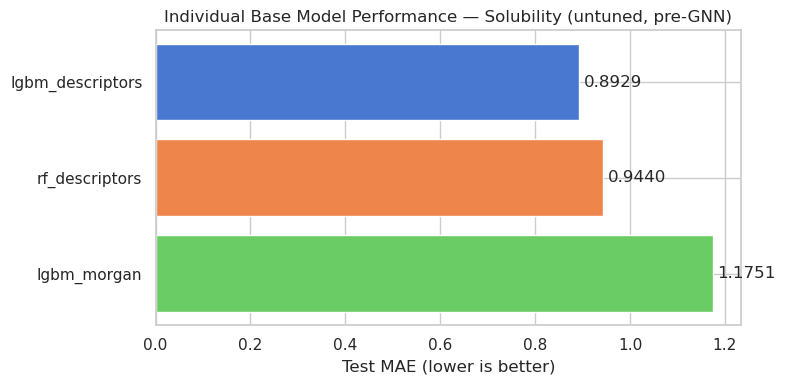

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(base_df['model'], base_df['mae'], color=sns.color_palette('muted', len(base_df)))
ax.set_xlabel('Test MAE (lower is better)')
ax.set_title('Individual Base Model Performance — Solubility (untuned, pre-GNN)')
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 2.5 — Base Model Tuning

The ensemble combination tuning in Section 5 only searches meta-weights/alpha — the base models ran with default hyperparameters.  Here we tune each base model individually with Optuna (5-fold CV, TPE sampler) and refit on the full training set.  This is the most impactful single lever available before adding the GNN.

In [6]:
TUNE_MODELS = ['lgbm_descriptors', 'lgbm_morgan', 'rf_descriptors']
print(f'Tuning: {TUNE_MODELS}\n')

for name in TUNE_MODELS:
    n_trials = 100 if 'lgbm' in name else 50
    print(f'── {name}  ({n_trials} trials) ──', flush=True)
    m = fitted_base_models[name]
    m.tune(X_train[name], y_train, n_trials=n_trials)
    preds   = m.predict(X_test[name])
    metrics = compute_metrics(y_test, preds, task_type='regression')
    test_predictions[name] = preds
    mask = base_df['model'] == name
    for col, val in metrics.items():
        if col in base_df.columns:
            base_df.loc[mask, col] = val
    print(f"  → MAE={metrics['mae']:.4f}  RMSE={metrics['rmse']:.4f}  R²={metrics['r2']:.3f}\n")

base_df.sort_values('mae').reset_index(drop=True)

Tuning: ['lgbm_descriptors', 'lgbm_morgan', 'rf_descriptors']

── lgbm_descriptors  (100 trials) ──
  → MAE=0.8950  RMSE=1.2758  R²=0.690

── lgbm_morgan  (100 trials) ──
  → MAE=1.1929  RMSE=1.5278  R²=0.556

── rf_descriptors  (50 trials) ──
  → MAE=0.9106  RMSE=1.2877  R²=0.685



,model,rmse,mae,r2,pearson_r
0,lgbm_descriptors,1.275796,0.894952,0.690336,0.830914
1,rf_descriptors,1.287671,0.910584,0.684544,0.827508
2,lgbm_morgan,1.527779,1.192853,0.555931,0.748803


## 2.6 — GNN Baseline

Train `MoleculeGNN` (GINEConv) as a standalone model to benchmark its individual performance before it joins the ensemble.  Training uses an internal 10% val split for early stopping; the TDC test set is not touched.

Training GNN baseline (this takes a few minutes)...

GNN  MAE=0.8190  RMSE=1.1471  R²=0.750


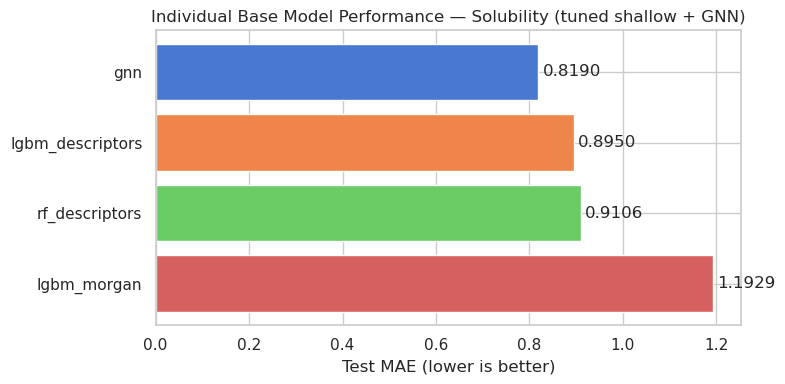

,model,rmse,mae,r2,pearson_r
0,gnn,1.147057,0.818956,0.749678,0.866081
1,lgbm_descriptors,1.275796,0.894952,0.690336,0.830914
2,rf_descriptors,1.287671,0.910584,0.684544,0.827508
3,lgbm_morgan,1.527779,1.192853,0.555931,0.748803


In [7]:
logging.getLogger('molgate.training.trainer').setLevel(logging.INFO)

print('Training GNN baseline (this takes a few minutes)...', flush=True)
gnn_raw     = create_model('gnn', task_type='regression')
gnn_wrapper = GNNModelWrapper(gnn_raw, gnn_raw.training_config, task_type='regression')
gnn_wrapper.fit(X_train['gnn'])

gnn_preds   = gnn_wrapper.predict(X_test['gnn'])
gnn_metrics = compute_metrics(y_test, gnn_preds, task_type='regression')
print(f"\nGNN  MAE={gnn_metrics['mae']:.4f}  RMSE={gnn_metrics['rmse']:.4f}  R²={gnn_metrics['r2']:.3f}")

fitted_base_models['gnn'] = gnn_wrapper
test_predictions['gnn']   = gnn_preds

gnn_row = pd.DataFrame([{'model': 'gnn', **gnn_metrics}])
base_df = pd.concat([base_df, gnn_row], ignore_index=True).sort_values('mae').reset_index(drop=True)

# Bar chart: all base models after tuning + GNN
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(base_df['model'], base_df['mae'],
               color=sns.color_palette('muted', len(base_df)))
ax.set_xlabel('Test MAE (lower is better)')
ax.set_title('Individual Base Model Performance — Solubility (tuned shallow + GNN)')
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

base_df

## 3. Prediction Correlation

Ensembles benefit most when base model errors are **uncorrelated** — if two models make the same mistakes, averaging them doesn't help.  A correlation < 0.9 between models suggests genuine diversity worth exploiting.

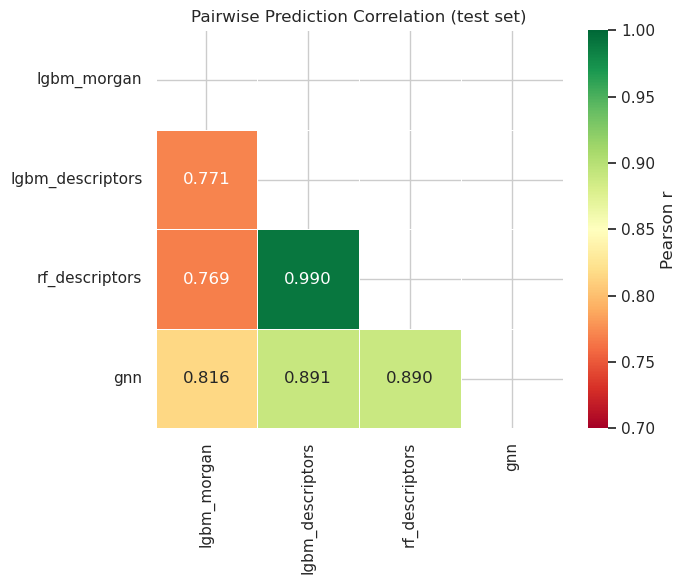

Pairs with r < 0.95 (most useful to combine):
  lgbm_morgan vs rf_descriptors: r=0.769
  lgbm_descriptors vs lgbm_morgan: r=0.771
  gnn vs lgbm_morgan: r=0.816
  gnn vs rf_descriptors: r=0.890
  gnn vs lgbm_descriptors: r=0.891


In [8]:
pred_df = pd.DataFrame(test_predictions)
corr = pred_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle redundant
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0.7, vmax=1.0, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Pearson r'},
)
ax.set_title('Pairwise Prediction Correlation (test set)')
plt.tight_layout()
plt.show()

# Pairs with correlation < 0.95 — most diversity to exploit
low_corr = [
    (i, j, corr.loc[i, j])
    for i in corr.index for j in corr.columns
    if i < j and corr.loc[i, j] < 0.95
]
if low_corr:
    print("Pairs with r < 0.95 (most useful to combine):")
    for i, j, r in sorted(low_corr, key=lambda x: x[2]):
        print(f"  {i} vs {j}: r={r:.3f}")
else:
    print("All pairs have r ≥ 0.95 — models may be too correlated to gain much from ensembling.")

## 4. Untuned Ensemble Comparison

Establish untuned baselines before running the Optuna study, so we can see how much tuning actually helps.

In [9]:
ENSEMBLE_MODELS = [
    'lgbm_morgan',
    'lgbm_descriptors',
    'rf_descriptors',
    'gnn'
]

def ensemble_X(split_X):
    return {k: split_X[k] for k in ENSEMBLE_MODELS}

eX_train = ensemble_X(X_train)
eX_val   = ensemble_X(X_val)
eX_test  = ensemble_X(X_test)

_base = {k: fitted_base_models[k] for k in ENSEMBLE_MODELS}

untuned_results = []

for ename, ecfg in [
    ('voting_untuned',   'ensemble_voting_fp'),
    ('blending_untuned', 'ensemble_blending'),
    ('stacking_untuned', 'ensemble_stacking'),
]:
    print(f'Fitting {ename}...', end=' ', flush=True)
    e = create_model(ecfg, task_type='regression', base_models=_base)
    if 'blending' in ename:
        e.fit(eX_train, y_train, eX_val, y_val)
    else:
        e.fit(eX_train, y_train)
    preds = e.predict(eX_test)
    metrics = compute_metrics(y_test, preds, task_type='regression')
    untuned_results.append({'model': ename, **metrics})
    print(f"MAE={metrics['mae']:.4f}")

untuned_df = pd.DataFrame(untuned_results)
untuned_df

Fitting voting_untuned... MAE=0.8364
Fitting blending_untuned... MAE=0.7998
Fitting stacking_untuned... MAE=0.8315


,model,rmse,mae,r2,pearson_r
0,voting_untuned,1.151446,0.836356,0.747758,0.868666
1,blending_untuned,1.120154,0.799811,0.761282,0.872727
2,stacking_untuned,1.146172,0.831518,0.750064,0.866997


## 5. Hyperparameter Tuning

Two-stage Optuna tuning: base models are fit once, then the combination mechanism (weights / meta_alpha) is searched against validation set predictions.  After the study the ensemble is re-fit end-to-end with the best params.

Increase `n_trials` for a more thorough search; 50 is a good balance for a dev run.

In [10]:
from molgate.models.tuning import tune_and_compare

_base = {k: fitted_base_models[k] for k in ENSEMBLE_MODELS}

ensembles_to_tune = {
    'voting':   create_model('ensemble_voting_fp',  task_type='regression', base_models=_base),
    'blending': create_model('ensemble_blending',   task_type='regression', base_models=_base),
    'stacking': create_model('ensemble_stacking',   task_type='regression', base_models=_base),
}

tuning_results = tune_and_compare(
    ensembles_to_tune,
    eX_train, y_train,
    eX_val,   y_val,
    eX_test,  y_test,
    n_trials=50,
    metric='mae',
)

tuning_results

,name,best_params,val_mae,test_rmse,test_mae,test_r2,test_pearson_r
0,blending,{'meta_alpha': 31.33637468475717},0.6269,1.1036,0.7845,0.7683,0.8770
1,voting,"{'weights': [0.08142577886231692, 0.1401326437...",0.6221,1.1063,0.7882,0.7672,0.8772
2,stacking,{'meta_alpha': 79.05781134843721},0.6778,1.1548,0.8303,0.7463,0.8661


## 6. Full Comparison

Combine individual base models, untuned ensembles, and tuned ensembles into one ranked table.

In [11]:
metric_cols = ['mae', 'rmse', 'r2']

# Base models
base_rows = base_df[['model'] + metric_cols].copy()
base_rows['category'] = 'base'

# Untuned ensembles
untuned_rows = untuned_df[['model'] + metric_cols].copy()
untuned_rows['category'] = 'untuned_ensemble'

# Tuned ensembles — rename columns to match
tuned_rows = tuning_results[['name', 'test_mae', 'test_rmse', 'test_r2']].copy()
tuned_rows.columns = ['model', 'mae', 'rmse', 'r2']
tuned_rows['model'] = tuned_rows['model'] + '_tuned'
tuned_rows['category'] = 'tuned_ensemble'

all_results = pd.concat([base_rows, untuned_rows, tuned_rows], ignore_index=True)
all_results = all_results.sort_values('mae').reset_index(drop=True)

# Highlight best per category
def highlight_best(s):
    is_min = s == s.min()
    return ['font-weight: bold' if v else '' for v in is_min]

all_results.style.apply(highlight_best, subset=['mae'])

,model,mae,rmse,r2,category
0,blending_tuned,0.784500,1.103600,0.768300,tuned_ensemble
1,voting_tuned,0.788200,1.106300,0.767200,tuned_ensemble
2,blending_untuned,0.799811,1.120154,0.761282,untuned_ensemble
3,gnn,0.818956,1.147057,0.749678,base
4,stacking_tuned,0.830300,1.154800,0.746300,tuned_ensemble
5,stacking_untuned,0.831518,1.146172,0.750064,untuned_ensemble
6,voting_untuned,0.836356,1.151446,0.747758,untuned_ensemble
7,lgbm_descriptors,0.894952,1.275796,0.690336,base
8,rf_descriptors,0.910584,1.287671,0.684544,base
9,lgbm_morgan,1.192853,1.527779,0.555931,base


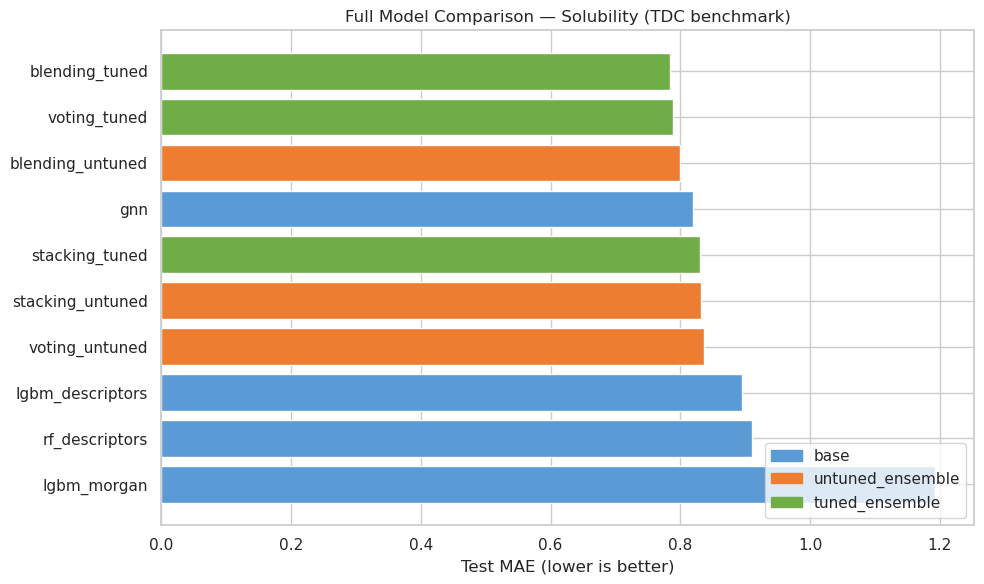

In [12]:
palette = {'base': '#5b9bd5', 'untuned_ensemble': '#ed7d31', 'tuned_ensemble': '#70ad47'}

fig, ax = plt.subplots(figsize=(10, 6))
for _, row in all_results.iterrows():
    ax.barh(row['model'], row['mae'], color=palette[row['category']])

# Legend
from matplotlib.patches import Patch
legend = [Patch(color=c, label=l) for l, c in palette.items()]
ax.legend(handles=legend, loc='lower right')

ax.set_xlabel('Test MAE (lower is better)')
ax.set_title('Full Model Comparison — Solubility (TDC benchmark)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Prediction Diversity of the Best Ensemble

Visualise where the best ensemble's errors concentrate compared to the best individual model.

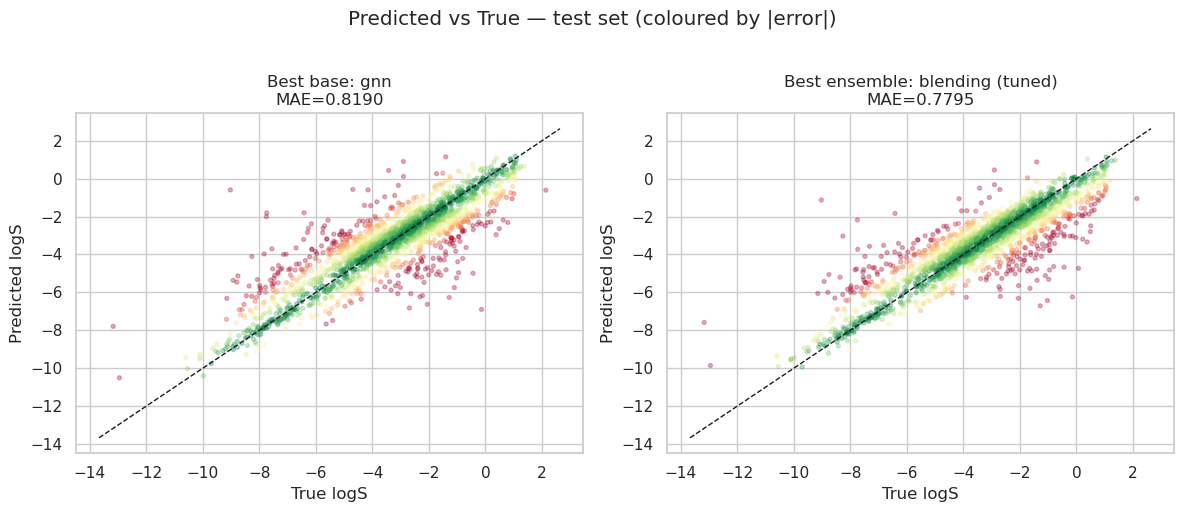

In [13]:
# Best individual model
best_base_name = base_df.iloc[0]['model']
best_base_preds = test_predictions[best_base_name]

# Best tuned ensemble (first row of tuning_results, already sorted by MAE)
best_ensemble_name = tuning_results.iloc[0]['name']
best_ensemble = ensembles_to_tune[best_ensemble_name]
best_ensemble_preds = best_ensemble.predict(eX_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in [
    (axes[0], best_base_preds,     f'Best base: {best_base_name}'),
    (axes[1], best_ensemble_preds, f'Best ensemble: {best_ensemble_name} (tuned)'),
]:
    errors = np.abs(preds - y_test)
    ax.scatter(y_test, preds, alpha=0.3, s=8, c=errors, cmap='RdYlGn_r', vmin=0, vmax=2)
    lims = [min(y_test.min(), preds.min()) - 0.5, max(y_test.max(), preds.max()) + 0.5]
    ax.plot(lims, lims, 'k--', lw=1, label='perfect')
    mae = np.mean(errors)
    ax.set_title(f'{title}\nMAE={mae:.4f}')
    ax.set_xlabel('True logS')
    ax.set_ylabel('Predicted logS')

plt.suptitle('Predicted vs True — test set (coloured by |error|)', y=1.02)
plt.tight_layout()
plt.show()

## 8. Blend Weights (BlendingEnsemble)

The meta-model coefficients show which base models the blender relies on most.  Negative weights indicate anticorrelated models that the meta-learner down-weights.

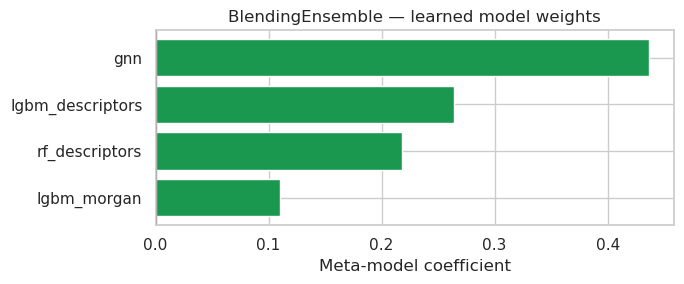

,model,weight
0,lgbm_morgan,0.110411
2,rf_descriptors,0.217726
1,lgbm_descriptors,0.263892
3,gnn,0.436819


In [14]:
blending_ensemble = ensembles_to_tune['blending']
weights = blending_ensemble.get_blend_weights()

wdf = pd.DataFrame(list(weights.items()), columns=['model', 'weight']).sort_values('weight')

fig, ax = plt.subplots(figsize=(7, 3))
colors = ['#d73027' if w < 0 else '#1a9850' for w in wdf['weight']]
ax.barh(wdf['model'], wdf['weight'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Meta-model coefficient')
ax.set_title('BlendingEnsemble — learned model weights')
plt.tight_layout()
plt.show()

wdf

## 9. Stacking Meta-Importances

The Ridge meta-learner's coefficients from StackingEnsemble reflect each base model's incremental contribution on top of the others.

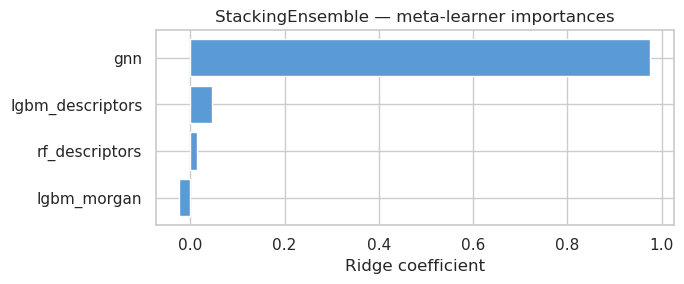

,model,importance
0,lgbm_morgan,-0.023838
2,rf_descriptors,0.014219
1,lgbm_descriptors,0.045058
3,gnn,0.975946


In [15]:
stacking_ensemble = ensembles_to_tune['stacking']
importances = stacking_ensemble.get_meta_importances()

idf = pd.DataFrame(list(importances.items()), columns=['model', 'importance']).sort_values('importance')

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(idf['model'], idf['importance'], color='#5b9bd5')
ax.set_xlabel('Ridge coefficient')
ax.set_title('StackingEnsemble — meta-learner importances')
plt.tight_layout()
plt.show()

idf

## 10. Verdict

Summary of findings and the model selected for production (Phase 7 API).

In [16]:
best_overall = all_results.iloc[0]
best_base    = all_results[all_results['category'] == 'base'].iloc[0]
best_tuned   = all_results[all_results['category'] == 'tuned_ensemble'].iloc[0]

improvement = (best_base['mae'] - best_tuned['mae']) / best_base['mae'] * 100

print(f"{'='*55}")
print(f"SOLUBILITY MODEL SELECTION SUMMARY")
print(f"{'='*55}")
print(f"  Best individual model : {best_base['model']:<25s}  MAE={best_base['mae']:.4f}")
print(f"  Best tuned ensemble   : {best_tuned['model']:<25s}  MAE={best_tuned['mae']:.4f}")
print(f"  Ensemble improvement  : {improvement:+.1f}% over best base")
print(f"  Overall winner        : {best_overall['model']:<25s}  MAE={best_overall['mae']:.4f}")
print(f"{'='*55}")
print()
print("Selected for production: ", best_overall['model'])
print("Next step              :  Phase 7 — serialise model + FastAPI endpoint")

SOLUBILITY MODEL SELECTION SUMMARY
  Best individual model : gnn                        MAE=0.8190
  Best tuned ensemble   : blending_tuned             MAE=0.7845
  Ensemble improvement  : +4.2% over best base
  Overall winner        : blending_tuned             MAE=0.7845

Selected for production:  blending_tuned
Next step              :  Phase 7 — serialise model + FastAPI endpoint


In [17]:
# Final ranked table (markdown-friendly)
display_cols = ['model', 'category', 'mae', 'rmse', 'r2']
print(all_results[display_cols].to_markdown(index=False, floatfmt='.4f'))

| model            | category         |    mae |   rmse |     r2 |
|:-----------------|:-----------------|-------:|-------:|-------:|
| blending_tuned   | tuned_ensemble   | 0.7845 | 1.1036 | 0.7683 |
| voting_tuned     | tuned_ensemble   | 0.7882 | 1.1063 | 0.7672 |
| blending_untuned | untuned_ensemble | 0.7998 | 1.1202 | 0.7613 |
| gnn              | base             | 0.8190 | 1.1471 | 0.7497 |
| stacking_tuned   | tuned_ensemble   | 0.8303 | 1.1548 | 0.7463 |
| stacking_untuned | untuned_ensemble | 0.8315 | 1.1462 | 0.7501 |
| voting_untuned   | untuned_ensemble | 0.8364 | 1.1514 | 0.7478 |
| lgbm_descriptors | base             | 0.8950 | 1.2758 | 0.6903 |
| rf_descriptors   | base             | 0.9106 | 1.2877 | 0.6845 |
| lgbm_morgan      | base             | 1.1929 | 1.5278 | 0.5559 |


## 11. TDC-Compliant Evaluation

Repeat the blending pipeline with **N_SEEDS** independent train/val splits on the same fixed TDC test set.  This gives us the mean ± std required for a leaderboard submission.

Architecture and `meta_alpha` are fixed from the tuning run above — we are measuring robustness, not re-tuning.

> **Runtime note**: each seed retrains all base models including the GNN (~5 min/seed on GPU).  Set `N_SEEDS = 5` for full TDC compliance; `N_SEEDS = 3` is faster for development.

In [46]:
from molgate.models.ensemble import BlendingEnsemble

SEEDS = [1, 2, 3, 4, 5]   # extend to [1, 2, 3, 4, 5] for full TDC submission

# Read meta_alpha directly from the fitted ensemble — tuning_results stores
# best_params as a string (str(dict)) so indexing it with a key fails.
BEST_META_ALPHA = ensembles_to_tune['blending'].meta_alpha

print(f"TDC-compliant evaluation  ({len(SEEDS)} seeds: {SEEDS})")
print(f"Models   : {ENSEMBLE_MODELS}")
print(f"meta_alpha (fixed): {BEST_META_ALPHA:.4f}")
print(f"Test set : {len(test_df)} molecules (TDC fixed)\n")

seed_maes = []

for seed in SEEDS:
    print(f"──── seed={seed} ──────────────────────────────", flush=True)

    s = random_split(train_val_df, val_frac=0.1, test_frac=0.0, seed=seed)
    tr_df, va_df = s['train'], s['val']

    X_tr = featurize(tr_df)
    X_va = featurize(va_df)
    y_tr = tr_df['y'].values
    y_va = va_df['y'].values

    seed_base = {}
    for name in ENSEMBLE_MODELS:
        if name == 'gnn':
            print(f"  training gnn (seed={seed})...", flush=True)
            g = create_model('gnn', task_type='regression')
            w = GNNModelWrapper(g, g.training_config, task_type='regression')
            w.fit(X_tr['gnn'])
            seed_base[name] = w
        else:
            m = create_model(name, task_type='regression')
            m.fit(X_tr[name], y_tr)
            seed_base[name] = m
            print(f"  {name} done", flush=True)

    blend = BlendingEnsemble(seed_base, task_type='regression', meta_alpha=BEST_META_ALPHA)
    blend.fit(
        {k: X_tr[k] for k in ENSEMBLE_MODELS}, y_tr,
        {k: X_va[k] for k in ENSEMBLE_MODELS}, y_va,
    )

    preds = blend.predict({k: X_test[k] for k in ENSEMBLE_MODELS})
    mae   = np.mean(np.abs(preds - y_test))
    seed_maes.append(mae)
    print(f"  → MAE = {mae:.4f}\n")

mean_mae = np.mean(seed_maes)
std_mae  = np.std(seed_maes)

print(f"{'='*50}")
print(f"TDC Result   MAE = {mean_mae:.4f} ± {std_mae:.4f}  (n={len(SEEDS)})")
print(f"Per-seed     : {dict(zip(SEEDS, [f'{m:.4f}' for m in seed_maes]))}")
print(f"{'='*50}")

TDC-compliant evaluation  (5 seeds: [1, 2, 3, 4, 5])
Models   : ['lgbm_morgan', 'lgbm_descriptors', 'rf_descriptors', 'gnn']
meta_alpha (fixed): 32.5842
Test set : 1968 molecules (TDC fixed)

──── seed=1 ──────────────────────────────
  lgbm_morgan done
  lgbm_descriptors done
  rf_descriptors done
  training gnn (seed=1)...
  → MAE = 0.7987

──── seed=2 ──────────────────────────────
  lgbm_morgan done
  lgbm_descriptors done
  rf_descriptors done
  training gnn (seed=2)...
  → MAE = 0.7821

──── seed=3 ──────────────────────────────
  lgbm_morgan done
  lgbm_descriptors done
  rf_descriptors done
  training gnn (seed=3)...
  → MAE = 0.7814

──── seed=4 ──────────────────────────────
  lgbm_morgan done
  lgbm_descriptors done
  rf_descriptors done
  training gnn (seed=4)...
  → MAE = 0.7943

──── seed=5 ──────────────────────────────
  lgbm_morgan done
  lgbm_descriptors done
  rf_descriptors done
  training gnn (seed=5)...
  → MAE = 0.8026

TDC Result   MAE = 0.7918 ± 0.0087  (n=5)
P

## 12. Model Serialization

Save the tuned blending ensemble to a self-describing checkpoint directory for use in the Phase 7 prediction API.

Layout on disk:
```
checkpoints/solubility/blending_tuned/
├── manifest.json          ← metrics, molgate version, created_at
├── ensemble_meta.json     ← ensemble type, feature_map, meta_alpha
├── meta.joblib            ← fitted Ridge meta-model
└── base/
    ├── lgbm_morgan.joblib
    ├── lgbm_descriptors.joblib
    ├── rf_descriptors.joblib
    └── gnn/               ← subdirectory: model.pt + manifest.json
        ├── manifest.json
        └── model.pt
```

After saving we reload the checkpoint and verify the round-trip MAE matches.

In [47]:
import json
from pathlib import Path
from molgate.serve.checkpoint import save_model, load_model, checkpoint_info

CHECKPOINT_ROOT = Path('/home/zhedd/molgate/checkpoints')

best_model = ensembles_to_tune['blending']

# Compute reference MAE from the CURRENT model state.
# tuning_results['test_mae'] is stale: all three ensembles share the same
# GNN reference, so the GNN gets retrained each time tune_and_compare
# processes an ensemble.  By the time stacking finishes, blending's GNN has
# stacking's weights.  Using predict() here ensures orig_mae and rt_mae are
# both measured on the same model that we actually save.
orig_preds = best_model.predict(eX_test)
orig_mae   = float(np.mean(np.abs(orig_preds - y_test)))
best_row   = tuning_results[tuning_results['name'] == 'blending'].iloc[0]
best_metrics = {
    'test_mae':  round(orig_mae, 4),
    'test_rmse': float(best_row['test_rmse']),
    'test_r2':   float(best_row['test_r2']),
}

ckpt_path = save_model(
    best_model,
    CHECKPOINT_ROOT / 'solubility' / 'blending_tuned',
    dataset='solubility',
    model_name='blending_tuned',
    metrics=best_metrics,
)
print(f"Saved to: {ckpt_path}\n")
print(json.dumps(checkpoint_info(ckpt_path), indent=2))

# Round-trip check
loaded   = load_model(ckpt_path)
rt_preds = loaded.predict(eX_test)
rt_mae   = float(np.mean(np.abs(rt_preds - y_test)))
print(f"\nRound-trip MAE : {rt_mae:.6f}  (original: {orig_mae:.6f})")
assert abs(rt_mae - orig_mae) < 1e-4, f"MAE mismatch after reload: {rt_mae:.6f} vs {orig_mae:.6f}"
print("Serialization verified ✓")

Saved to: /home/zhedd/molgate/checkpoints/solubility/blending_tuned

{
  "model_class": "BlendingEnsemble",
  "model_name": "blending_tuned",
  "dataset": "solubility",
  "task_type": "regression",
  "metrics": {
    "test_mae": 0.7843,
    "test_rmse": 1.0997,
    "test_r2": 0.7699
  },
  "molgate_version": "0.1.0",
  "created_at": "2026-06-05T05:58:59.232323+00:00"
}

Round-trip MAE : 0.784349  (original: 0.784349)
Serialization verified ✓
